# IA 340 Mini Project

## Public Library Funding and Use Correlation

Research Question 1. How does funding affect use of libraries?

Source: State of Conneticut
Link: https://catalog.data.gov/dataset/public-libraries-b1aaf
    This source shows the individual library services and finance data to the town level. The data shows amount of library visits, library visits per capita, total registered borrowers, percent of residents with library cards, amount of books in collection, and various expenditures. The time period of this dataset is from 1996 to 2025. This dataset relates to my question because it shows not only the library's data, but also gives information about the town that it resides in. I chose the research question because I am curious to see if libraries are still seeing the same attendance today and if the funding is still as high as it was before digital libraries.

Time Period: 1996 to 2024

In [1]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import os
import io
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('s3://harrigan-ia340/Public_Libraries.csv') # load the data from s3
df.head() #show the top 5 rows

,Fiscal Year,Library,County,AENGLC Rank,Population of Service Area,Total Library Visits,Library Visits Per Capita Served,Total Registered Borrowers,Percent of Residents with Library Cards,Reference Questions,...,Total Collection,Collection Per Capita Served,Total Operating Income,Operating Income Per Capita,Town Tax Appropriation for Library,Tax Appropriation Per Capita Served,Library Materials Expenditures,Wages & Salaries Expenditures,Operating Expenditures,Operating Expenditures Per Capita
0,1996,Andover,Tolland,109.0,2815.0,15000.0,5.3,1313.0,0.47,499.0,...,15285.0,5.4,56300.0,20.00,52915.0,18.80,10073.0,30996.0,44290.0,15.7
1,1996,Ansonia,New Haven,158.0,17825.0,91756.0,5.1,6952.0,0.39,NaN,...,63685.0,3.6,320679.0,17.99,323503.0,18.15,45874.0,201621.0,270658.0,15.2
2,1996,Ashford-Babcock,Windham,131.0,3969.0,8665.0,2.2,1360.0,0.34,207.0,...,23818.0,6.0,111699.0,28.14,106713.0,26.89,11508.0,62295.0,82769.0,20.9
3,1996,Avon,Hartford,19.0,14143.0,162893.0,11.5,8808.0,0.62,15283.0,...,74903.0,5.3,685678.0,48.48,602831.0,42.62,92711.0,340400.0,516583.0,36.5
4,1996,Beacon Falls,New Haven,129.0,5351.0,7000.0,1.3,1379.0,0.26,400.0,...,10042.0,1.9,40806.0,7.63,39256.0,7.34,4298.0,21585.0,39165.0,7.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5278 entries, 0 to 5277
Data columns (total 27 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Fiscal Year                                         5278 non-null   int64  
 1   Library                                             5278 non-null   object 
 2   County                                              5278 non-null   object 
 3   AENGLC Rank                                         5161 non-null   float64
 4   Population of Service Area                          4814 non-null   float64
 5   Total Library Visits                                5059 non-null   float64
 6   Library Visits Per Capita Served                    5043 non-null   float64
 7   Total Registered Borrowers                          5173 non-null   float64
 8   Percent of Residents with Library Cards             5159 non-null   float64
 9

In [5]:
df.describe()

,Fiscal Year,AENGLC Rank,Population of Service Area,Total Library Visits,Library Visits Per Capita Served,Total Registered Borrowers,Percent of Residents with Library Cards,Reference Questions,Reference Questions Per Capita Served,Total Circulation,...,Total Collection,Collection Per Capita Served,Total Operating Income,Operating Income Per Capita,Town Tax Appropriation for Library,Tax Appropriation Per Capita Served,Library Materials Expenditures,Wages & Salaries Expenditures,Operating Expenditures,Operating Expenditures Per Capita
count,5278.000000,5161.000000,4814.000000,5059.000000,5043.000000,5173.000000,5159.000000,4874.000000,4845.000000,5.225000e+03,...,5201.000000,5150.000000,5.215000e+03,5171.000000,5.205000e+03,5160.000000,5.195000e+03,5.124000e+03,5.211000e+03,5180.000000
mean,2010.003410,84.506879,21247.535937,107157.471042,5.362425,9295.665765,0.476718,19744.192039,0.738092,1.502103e+05,...,82797.331504,5.421448,9.376033e+05,45.400722,8.093251e+05,34.949243,9.568891e+04,5.658243e+05,9.226869e+05,44.205837
std,8.346599,49.290179,25035.622607,139066.918784,3.914244,11518.957252,0.226061,39493.674615,0.856531,1.885630e+05,...,87323.107208,3.690736,1.447204e+06,36.727556,1.250240e+06,24.807234,1.444297e+05,8.288948e+05,1.405750e+06,35.253294
min,1996.000000,1.000000,632.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2003.000000,41.000000,5840.000000,17740.000000,2.600000,2470.000000,0.330000,1500.000000,0.200000,2.996500e+04,...,28654.000000,3.300000,1.756065e+05,25.540000,1.053540e+05,20.157500,1.765350e+04,1.048668e+05,1.699255e+05,24.000000
50%,2010.000000,84.000000,13095.000000,55000.000000,4.600000,5186.000000,0.460000,5771.500000,0.500000,7.880600e+04,...,56952.000000,4.700000,4.659760e+05,37.490000,3.751620e+05,32.060000,4.824600e+04,2.780260e+05,4.616200e+05,37.200000
75%,2017.000000,127.000000,25843.250000,132384.500000,7.200000,11474.000000,0.620000,19112.250000,0.900000,2.005130e+05,...,103307.000000,6.600000,1.054585e+06,54.465000,9.587710e+05,45.012500,1.075920e+05,6.591418e+05,1.039528e+06,54.325000
max,2024.000000,169.000000,148698.000000,989139.000000,25.700000,110832.000000,1.570000,573513.000000,8.100000,1.546762e+06,...,918170.000000,38.000000,1.702784e+07,439.970000,9.987656e+06,198.870000,1.339528e+06,7.351934e+06,1.343523e+07,418.020000


In [6]:
df = df.dropna(axis=1, how="all")

In [7]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 0 duplicate rows


In [14]:
df.columns

Index(['fiscal_year', 'library', 'county', 'aenglc_rank',
       'population_of_service_area', 'total_library_visits',
       'library_visits_per_capita_served', 'total_registered_borrowers',
       'percent_of_residents_with_library_cards', 'reference_questions',
       'reference_questions_per_capita_served', 'total_circulation',
       'circulation_per_capita_served',
       'total_programs_(synchronous_+_prerecorded)',
       'total_program_attendance_&_views',
       'total_program_attendance_&_views_per_capita_served',
       'use_of_public_internet_computers', 'total_collection',
       'collection_per_capita_served', 'total_operating_income',
       'operating_income_per_capita', 'town_tax_appropriation_for_library',
       'tax_appropriation_per_capita_served', 'library_materials_expenditures',
       'wages_&_salaries_expenditures', 'operating_expenditures',
       'operating_expenditures_per_capita'],
      dtype='object')

In [22]:
df['fiscal_year'].head()

0    1996
1    1996
2    1996
3    1996
4    1996
Name: fiscal_year, dtype: int64

In [10]:
df.columns = [c.strip().replace(" ", "_").lower() for c in df.columns]
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

In [16]:
numeric_candidates = [
    "population", "total_circulation", "visits", "expenditure_total",
    "operating_expenditure", "program_attendance", "total_hours"
]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [19]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5278 entries, 0 to 5277
Data columns (total 27 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   fiscal_year                                         5278 non-null   int64  
 1   library                                             5278 non-null   object 
 2   county                                              5278 non-null   object 
 3   aenglc_rank                                         5161 non-null   float64
 4   population_of_service_area                          4814 non-null   float64
 5   total_library_visits                                5059 non-null   float64
 6   library_visits_per_capita_served                    5043 non-null   float64
 7   total_registered_borrowers                          5173 non-null   float64
 8   percent_of_residents_with_library_cards             5159 non-null   float64
 9

None

In [20]:
df["expected_visits"] = df["library_visits_per_capita_served"] * df["population_of_service_area"]
df["expected_circulation"] = df["circulation_per_capita_served"] * df["population_of_service_area"]

# Check for big mismatches
visit_diff = (df["expected_visits"] - df["total_library_visits"]).abs() / df["total_library_visits"]
print("Average relative difference (visits):", visit_diff.mean())

circ_diff = (df["expected_circulation"] - df["total_circulation"]).abs() / df["total_circulation"]
print("Average relative difference (circulation):", circ_diff.mean())

Average relative difference (visits): 0.010564784174455593
Average relative difference (circulation): 0.010274372235968634


In [21]:
duplicates = df[df.duplicated(subset=["library", "fiscal_year"], keep=False)]
print("Duplicate records:", len(duplicates))

Duplicate records: 0


In [23]:
invalid = df[
    (df["population_of_service_area"] <= 0) |
    (df["operating_expenditures_per_capita"] < 0) |
    (df["library_visits_per_capita_served"] < 0)
]
print("Invalid rows based on logical rules:", len(invalid))

Invalid rows based on logical rules: 0


In [24]:
df.isna().sum()

fiscal_year                                              0
library                                                  0
county                                                   0
aenglc_rank                                            117
population_of_service_area                             464
total_library_visits                                   219
library_visits_per_capita_served                       235
total_registered_borrowers                             105
percent_of_residents_with_library_cards                119
reference_questions                                    404
reference_questions_per_capita_served                  433
total_circulation                                       53
circulation_per_capita_served                           70
total_programs_(synchronous_+_prerecorded)             168
total_program_attendance_&_views                       191
total_program_attendance_&_views_per_capita_served     213
use_of_public_internet_computers                      19

## Import, Clean, and Process Steps

I imported the dataset and showed the top 5 rows to see what columns and data made up the dataset

Then I used .info to show all of the columns and what type of values the columns contained. I saw that the fiscal year column was in interger, and I decided to keep it in interger as I previously changed it to datetime format and pandas had a hard time reading the format and ended up deleting the original years.

I checked for duplicate rows and deleted any possible duplicate rows.

I then changed all of the column names to change any spaces to "_" and change all uppercase letters to lowercase numbers

I then changed all of the numeric columns' data to numeric values and deleted duplicate years.

I checked to make sure that my data made sense by calculating expected visits and making sure it was reasonably close to the values in the dataset. The relative difference were 0.010564784174455593 and 0.010274372235968634, which are very small values.

Lastly, I checked to make sure all of the data still made sense by checking to see if there were any rows that had less than 0 population, operating expenditures, and library visits per capita. 



In [25]:
df = df.sort_values(["library", "fiscal_year"])
df["spending_growth_rate"] = (
    df.groupby("library")["operating_expenditures_per_capita"].pct_change()
)
df["visits_growth_rate"] = (
    df.groupby("library")["library_visits_per_capita_served"].pct_change()
)

In [26]:
df.head()

,fiscal_year,library,county,aenglc_rank,population_of_service_area,total_library_visits,library_visits_per_capita_served,total_registered_borrowers,percent_of_residents_with_library_cards,reference_questions,...,town_tax_appropriation_for_library,tax_appropriation_per_capita_served,library_materials_expenditures,wages_&_salaries_expenditures,operating_expenditures,operating_expenditures_per_capita,expected_visits,expected_circulation,spending_growth_rate,visits_growth_rate
0,1996,Andover,Tolland,109.0,2815.0,15000.0,5.3,1313.0,0.47,499.0,...,52915.0,18.80,10073.0,30996.0,44290.0,15.7,14919.5,15764.0,NaN,NaN
183,1997,Andover,Tolland,109.0,2782.0,15000.0,5.4,1676.0,0.60,414.0,...,56570.0,20.33,10203.0,33442.0,48173.0,17.3,15022.8,17248.4,0.101911,0.018868
361,1998,Andover,Tolland,113.0,2740.0,9000.0,3.3,1687.0,0.62,379.0,...,61620.0,22.49,14547.0,35669.0,58301.0,21.3,9042.0,15344.0,0.231214,-0.388889
541,1999,Andover,Tolland,109.0,2850.0,8500.0,3.0,1263.0,0.44,344.0,...,66422.0,24.24,9487.0,41449.0,56876.0,20.0,8550.0,16245.0,-0.061033,-0.090909
720,2000,Andover,Tolland,108.0,2850.0,9500.0,3.3,1263.0,0.44,590.0,...,72606.0,25.48,9168.0,43549.0,80505.0,28.2,9405.0,18240.0,0.410000,0.100000


## New Variable
The new variables (spending growth rate, and visits growth rate) show the change of visits and spending every year. This shows how libraries' funding and visits are changing throughout the years and show times where funding and visits went up or down.

In [32]:
df_2005 = df[df['fiscal_year'] == 2005]

# Compute spending per capita
df_2005['spending_per_capita'] = (
    df_2005['town_tax_appropriation_for_library'] / df_2005['population_of_service_area']
)

# Sort and get top 10 libraries
top10_2005 = (
    df_2005[['library', 'town_tax_appropriation_for_library', 'population_of_service_area', 'spending_per_capita']]
    .sort_values(by='spending_per_capita', ascending=False)
    .head(10)
)

# Display results in a DataFrame
top10_2005

,library,town_tax_appropriation_for_library,population_of_service_area,spending_per_capita
1802,Westport,3278020.0,26564.0,123.400843
1670,Darien,2187212.0,20547.0,106.449214
1696,Greenwich,5843473.0,62317.0,93.770127
1805,Wilton,1535844.0,17965.0,85.490899
1691,Farmington,1795710.0,24682.0,72.753829
1731,New Canaan,1438215.0,19965.0,72.036814
1813,Woodbridge,627869.0,9289.0,67.592744
1639,Avon,1134794.0,16992.0,66.784016
1757,Portland,589290.0,9340.0,63.093148
1684,Easton,458891.0,7488.0,61.283520


The table above shows the 10 libraries with the highest spending per capita for the year 2005.

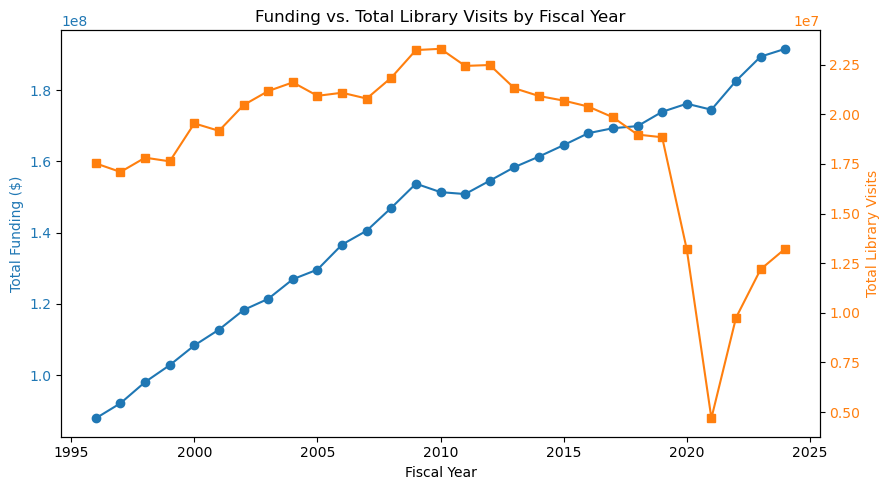

In [38]:
import matplotlib.pyplot as plt

# Group totals by year
yearly = df.groupby('fiscal_year')[['town_tax_appropriation_for_library', 'total_library_visits']].sum()

# Create figure and twin axes
fig, ax1 = plt.subplots(figsize=(9,5))

# Plot funding (left axis)
ax1.set_title('Funding vs. Total Library Visits by Fiscal Year')
ax1.set_xlabel('Fiscal Year')
ax1.set_ylabel('Total Funding ($)', color='tab:blue')
ax1.plot(yearly.index, yearly['town_tax_appropriation_for_library'], color='tab:blue', marker='o', label='Funding ($)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot visits (right axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Total Library Visits', color='tab:orange')
ax2.plot(yearly.index, yearly['total_library_visits'], color='tab:orange', marker='s', label='Visits')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add grid and layout
fig.tight_layout()
plt.show()


## Chart 1
This chart compares the total funding for all of the libraries in Conneticut and the total library visits for all of Conneticut. The graph shows that funding has steadily increased, but the total visits decreased significantly in 2020, due to COVID. The visits are starting to rise again, but is nowhere near the level of the funding. 

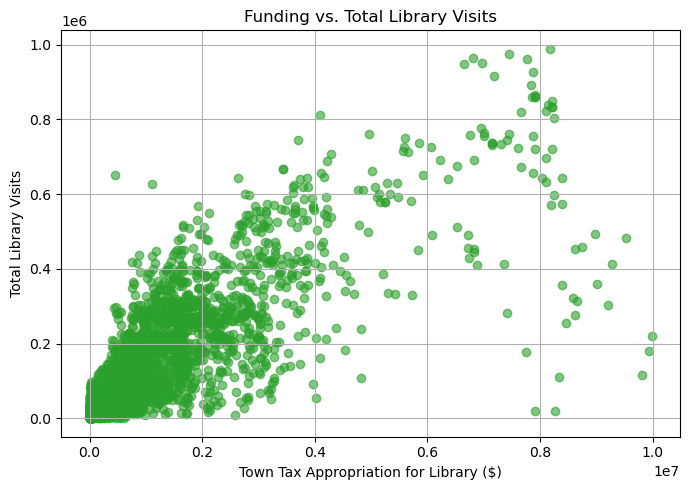

In [36]:
plt.figure(figsize=(7,5))
plt.scatter(df['town_tax_appropriation_for_library'], df['total_library_visits'],
            alpha=0.6, color='tab:green')
plt.title('Funding vs. Total Library Visits')
plt.xlabel('Town Tax Appropriation for Library ($)')
plt.ylabel('Total Library Visits')
plt.grid(True)
plt.tight_layout()
plt.show()

# Chart 2
This chart shows the funding for each library and the total visits for each library. This is similar to Chart 1, but it shows the data at a micro level, and shows outliers in the data. There is a positive correlation between the funding for libraries and the total visits for the libraries.

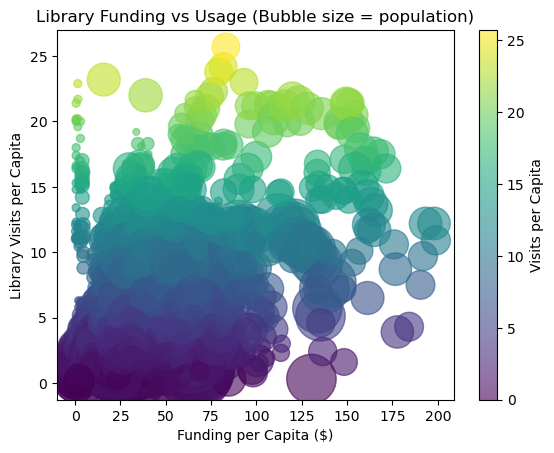

In [43]:
plt.scatter(
    df['tax_appropriation_per_capita_served'],
    df['library_visits_per_capita_served'],
    s=df['population_of_service_area']/50,  # scale bubble size
    alpha=0.6,
    c=df['library_visits_per_capita_served'],
    cmap='viridis'
)
plt.xlabel('Funding per Capita ($)')
plt.ylabel('Library Visits per Capita')
plt.title('Library Funding vs Usage (Bubble size = population)')
plt.colorbar(label='Visits per Capita')
plt.show()

## Chart 3
This chart compares the funding for the libraries per capita, which averages for the population of the county, and the library visits per capita. It is hard to determine a correlation for this graph, which means that there is not a strong correlation between funding and visits per capita. 

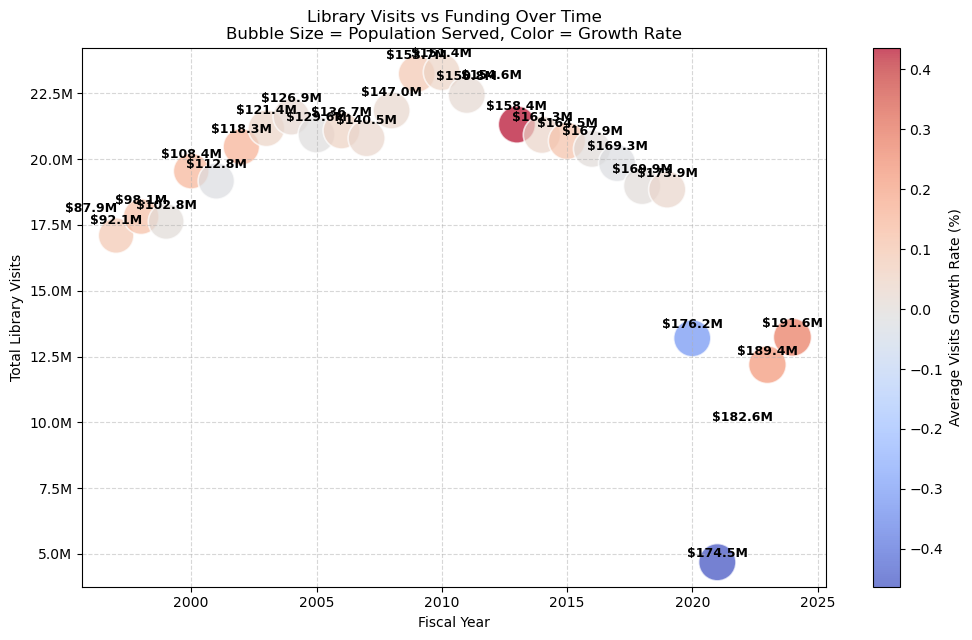

In [56]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12,7))

# Example plot
scatter = ax.scatter(
    yearly['fiscal_year'],
    yearly['total_library_visits'],
    s=yearly['population_of_service_area']/5000,
    c=yearly['visits_growth_rate'],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='w',
    linewidth=1.2
)

# Format Y-axis with 'K' for thousands or 'M' for millions
def millions(x, pos):
    'The two args are the value and tick position'
    return f'{x*1e-6:.1f}M'

ax.yaxis.set_major_formatter(mtick.FuncFormatter(millions))

# Colorbar for growth rate
cbar = plt.colorbar(scatter)
cbar.set_label('Average Visits Growth Rate (%)')

# Labels and title
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Total Library Visits')
ax.set_title('Library Visits vs Funding Over Time\nBubble Size = Population Served, Color = Growth Rate')

# Annotate funding
for i, row in yearly.iterrows():
    ax.text(row['fiscal_year'], row['total_library_visits']*1.02, f"${row['funding_million']:.1f}M",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Chart 4
This chart compares library visits, funding, and growth rate over time. The shade of the bubbles are the growth rate of the libraries, with blue being a negative growth rate and red being positive. The only negative years are the years of covid. 